In [1]:
from google.colab import files
uploaded = files.upload()  # casting_data.zip

Saving casting_data.zip to casting_data.zip


In [2]:
import zipfile
with zipfile.ZipFile("casting_data.zip", "r") as zip_ref:
    zip_ref.extractall("casting_data")
print("Dataset extracted successfully")

Dataset extracted successfully


In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

from tensorflow.keras import layers, models
from sklearn.metrics import classification_report, confusion_matrix

train_dir = "casting_data/casting_data/casting_data/train"
test_dir  = "casting_data/casting_data/casting_data/test"

print("GPU available:", tf.config.list_physical_devices('GPU'))

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [4]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
class_names = ["ok_front", "def_front"]  # 0 = Non-defective, 1 = Defective

train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, class_names=class_names, validation_split=0.20,
    subset="training", seed=42, image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, label_mode="binary"
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir, class_names=class_names, validation_split=0.20,
    subset="validation", seed=42, image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, label_mode="binary"
)

test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir, class_names=class_names, image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE, label_mode="binary", shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
test_dataset = test_dataset.prefetch(AUTOTUNE)

Found 6633 files belonging to 2 classes.
Using 5307 files for training.
Found 6633 files belonging to 2 classes.
Using 1326 files for validation.
Found 715 files belonging to 2 classes.


In [5]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),   # simulates a part viewed/rotated 180 degrees
    layers.RandomRotation(0.05),       # simulates slight camera/product misalignment
    layers.RandomZoom(0.10),           # simulates camera distance variation
    layers.RandomContrast(0.10)        # simulates lighting differences on the line
], name="data_augmentation")

In [6]:
model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),   # 224x224x3: balances visual detail vs. compute cost

    data_augmentation,
    layers.Rescaling(1.0 / 255),         # normalizes pixel values from [0,255] to [0,1] for stable training

    layers.Conv2D(32, 3, activation="relu"),   # learns simple features: edges, lines, surface texture
    layers.MaxPooling2D(),                     # reduces spatial size, keeps strongest features

    layers.Conv2D(64, 3, activation="relu"),   # learns more complex shapes
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),  # learns high-level patterns (cracks, holes, rough edges)
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),   # summarizes feature maps with far fewer params than Flatten()

    layers.Dropout(0.40),              # randomly disables 40% of neurons to reduce overfitting

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="sigmoid")   # single neuron + sigmoid -> probability of "Defective"
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,569 (396.75 KB)

 Trainable params: 101,569 (396.75 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),  # adaptive, works well with little tuning
    loss="binary_crossentropy",    # correct loss for a 2-class problem
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")   # recall on Defective is the critical metric here
    ]
)

In [8]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
        # stops training once validation performance plateaus, prevents overfitting
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2
        # lowers learning rate when improvement stalls, allows finer weight updates
    )
]

In [9]:
history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,           # max epochs; early stopping likely ends it sooner
    callbacks=callbacks
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 19s 67ms/step - accuracy: 0.5532 - loss: 0.6894 - precision: 0.5598 - recall: 0.9513 - val_accuracy: 0.5897 - val_loss: 0.6821 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.5608 - loss: 0.6857 - precision: 0.5608 - recall: 1.0000 - val_accuracy: 0.5897 - val_loss: 0.6806 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.5606 - loss: 0.6816 - precision: 0.5629 - recall: 0.9688 - val_accuracy: 0.5897 - val_loss: 0.6707 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 61ms/step - accuracy: 0.5677 - loss: 0.6780 - precision: 0.5744 - recall: 0.8844 - val_accuracy: 0.5897 - val_loss: 0.6459 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - 

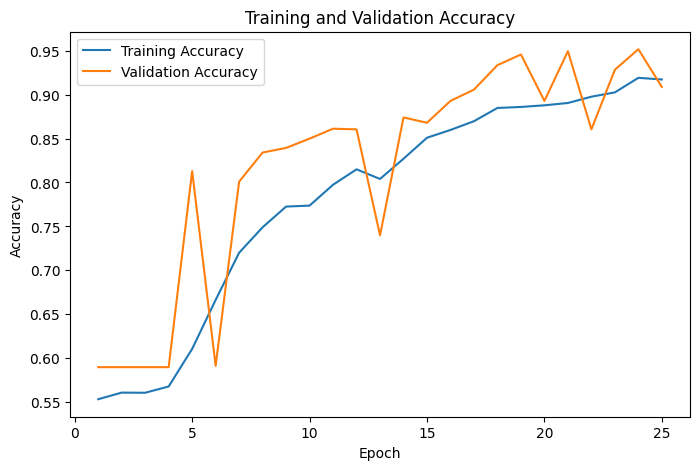

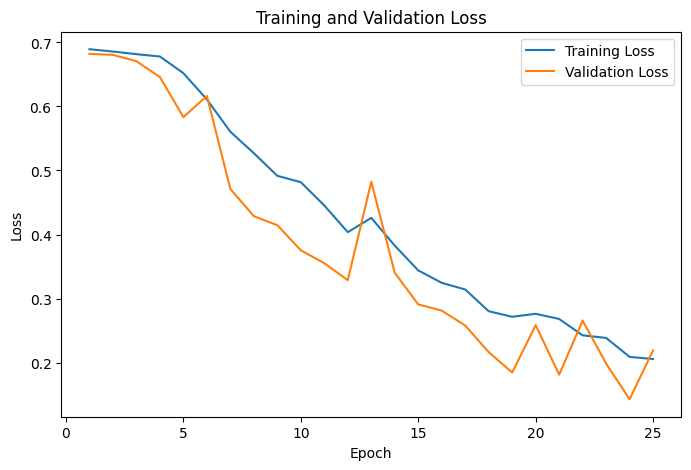

In [10]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, acc, label="Training Accuracy")
plt.plot(epochs_range, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend(); plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend(); plt.show()

In [11]:
test_results = model.evaluate(test_dataset)
print("Test results [loss, accuracy, precision, recall]:", test_results)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.9566 - loss: 0.1439 - precision: 0.9774 - recall: 0.9536
Test results [loss, accuracy, precision, recall]: [0.14387688040733337, 0.9566433429718018, 0.9773755669593811, 0.9536423683166504]


In [12]:
probabilities = model.predict(test_dataset)
predictions = (probabilities.flatten() >= 0.5).astype(int)

actual_labels = np.concatenate([
    labels.numpy().flatten() for images, labels in test_dataset
]).astype(int)

print(classification_report(
    actual_labels, predictions,
    target_names=["Non-defective", "Defective"]
))

matrix = confusion_matrix(actual_labels, predictions)
print("Confusion matrix:\n", matrix)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step
               precision    recall  f1-score   support

Non-defective       0.92      0.96      0.94       262
    Defective       0.98      0.95      0.97       453

     accuracy                           0.96       715
    macro avg       0.95      0.96      0.95       715
 weighted avg       0.96      0.96      0.96       715

Confusion matrix:
 [[252  10]
 [ 21 432]]


In [13]:
test_ok_dir = os.path.join(test_dir, "ok_front")
test_def_dir = os.path.join(test_dir, "def_front")

def predict_product(image_path, model, threshold=0.50):
    image = tf.keras.utils.load_img(image_path, target_size=(224, 224))
    image_array = tf.keras.utils.img_to_array(image)
    image_array = tf.expand_dims(image_array, axis=0)
    probability = float(model.predict(image_array, verbose=0)[0][0])
    label = "Defective" if probability >= threshold else "Non-defective"
    action = "Send for manual inspection" if probability >= threshold else "Product may proceed"
    print(f"Prediction: {label}")
    print(f"Probability: {probability:.2%}")
    print(f"Action: {action}")

samples = [
    (os.path.join(test_ok_dir, f), "Non-defective") for f in os.listdir(test_ok_dir)[:3]
] + [
    (os.path.join(test_def_dir, f), "Defective") for f in os.listdir(test_def_dir)[:2]
]

for path, actual in samples:
    print(f"--- Actual: {actual} ---")
    predict_product(path, model, threshold=0.50)
    print()

--- Actual: Non-defective ---
Prediction: Non-defective
Probability: 9.06%
Action: Product may proceed

--- Actual: Non-defective ---
Prediction: Non-defective
Probability: 6.37%
Action: Product may proceed

--- Actual: Non-defective ---
Prediction: Non-defective
Probability: 1.31%
Action: Product may proceed

--- Actual: Defective ---
Prediction: Defective
Probability: 70.93%
Action: Send for manual inspection

--- Actual: Defective ---
Prediction: Defective
Probability: 100.00%
Action: Send for manual inspection



In [18]:
model_v2 = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    data_augmentation,
    layers.Rescaling(1.0 / 255),

    layers.Conv2D(32, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation="relu"),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dropout(0.20),   # CHANGED from 0.40 -> 0.20

    layers.Dense(64, activation="relu"),

    layers.Dense(1, activation="sigmoid")
])

model_v2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.Precision(name="precision"), tf.keras.metrics.Recall(name="recall")]
)

# Fresh callbacks — do NOT reuse the original `callbacks` list, it's stateful
# and still remembers the first model's best val_loss, which would sabotage this run
callbacks_v2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2
    )
]

history_v2 = model_v2.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=25,
    callbacks=callbacks_v2
)

Epoch 1/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.5600 - loss: 0.6878 - precision: 0.5605 - recall: 0.9983 - val_accuracy: 0.5897 - val_loss: 0.6788 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 2/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 20s 64ms/step - accuracy: 0.5589 - loss: 0.6858 - precision: 0.5611 - recall: 0.9798 - val_accuracy: 0.5897 - val_loss: 0.6757 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 3/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.5659 - loss: 0.6819 - precision: 0.5680 - recall: 0.9429 - val_accuracy: 0.5897 - val_loss: 0.6638 - val_precision: 0.5897 - val_recall: 1.0000 - learning_rate: 0.0010
Epoch 4/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 10s 63ms/step - accuracy: 0.5983 - loss: 0.6678 - precision: 0.6013 - recall: 0.8417 - val_accuracy: 0.7489 - val_loss: 0.6263 - val_precision: 0.8046 - val_recall: 0.7583 - learning_rate: 0.0010
Epoch 5/25
166/166 ━━━━━━━━━━━━━━━━━━━━ 11s 66ms/step - 

In [19]:
test_results_v2 = model_v2.evaluate(test_dataset)
print("Model v2 (dropout=0.20) test results [loss, accuracy, precision, recall]:", test_results_v2)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.9832 - loss: 0.0881 - precision: 0.9977 - recall: 0.9757
Model v2 (dropout=0.20) test results [loss, accuracy, precision, recall]: [0.08805274963378906, 0.9832167625427246, 0.9977426528930664, 0.9757174253463745]


In [20]:
probabilities_v2 = model_v2.predict(test_dataset)
predictions_v2 = (probabilities_v2.flatten() >= 0.5).astype(int)

print(classification_report(
    actual_labels, predictions_v2,
    target_names=["Non-defective", "Defective"]
))

matrix_v2 = confusion_matrix(actual_labels, predictions_v2)
print("Confusion matrix (v2):\n", matrix_v2)

23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
               precision    recall  f1-score   support

Non-defective       0.96      1.00      0.98       262
    Defective       1.00      0.98      0.99       453

     accuracy                           0.98       715
    macro avg       0.98      0.99      0.98       715
 weighted avg       0.98      0.98      0.98       715

Confusion matrix (v2):
 [[261   1]
 [ 11 442]]


## Bonus Experiment

**Original Design:** Dropout = 0.40 (after GlobalAveragePooling2D)
**Changed Design:** Dropout = 0.20
**Reason for Change:** To test whether the original dropout rate was too aggressive for this dataset size, potentially limiting the model's ability to learn from the ~6,600 training images.

**Original Accuracy:** 95.7% (test set)
**New Accuracy:** 98.3% (test set)

**Observation:** Lowering dropout from 0.40 to 0.20 improved every test metric — accuracy rose from 95.7% to 98.3%, defective-class recall rose from 95.4% to 97.6%, and false negatives dropped from 21 to 11 (out of 453 defective test images). This suggests 0.40 dropout was likely too strong a regularizer for this dataset/model size combination, discarding useful learned features during training. A dropout of 0.20 still provided enough regularization to avoid overfitting (training and validation metrics tracked closely throughout training) while allowing the model to retain more of its learned capacity.

## Design Decision Table

| Design Decision | Selected Value | Reason |
|---|---|---|
| Image size | 224 x 224 | Balance between detail and computation |
| Problem type | Binary classification | Two output classes (defective/non-defective) |
| Model type | CNN | Suitable for learning visual patterns from images |
| Conv filters | 32, 64, 128 | Learn increasingly complex features with depth |
| Kernel size | 3 x 3 | Efficient local feature extraction |
| Hidden activation | ReLU | Efficient, allows learning non-linear patterns |
| Pooling | MaxPooling2D | Reduces feature dimensions, retains key features |
| Output activation | Sigmoid | Produces a binary probability (0 to 1) |
| Optimizer | Adam | Adaptive learning rate, works well with little tuning |
| Learning rate | 0.001 (initial) | Reasonable Adam starting value |
| Loss function | Binary Cross-Entropy | Correct loss for a 2-class problem |
| Batch size | 32 | Balanced memory usage and stable weight updates |
| Epochs | Max 25 | Enough training time, with early stopping as a safeguard |
| Dropout | 0.20 (revised from 0.40) | 0.40 over-regularized the model; 0.20 improved accuracy from 95.7% to 98.3% |
| Augmentation | Flip, rotation, zoom, contrast | Improves robustness to real-world camera/lighting variation |
| Metrics | Accuracy, Precision, Recall | Recall on Defective is critical to avoid shipping defective parts |

## Conclusion

The CNN successfully classifies casting products as defective or non-defective, achieving 98.3% test accuracy after tuning the dropout rate. Documenting each design choice showed that regularization strength (dropout) had a larger impact on this dataset than expected, and the bonus experiment confirmed a lighter dropout rate better suited this problem's data size and complexity.